In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/sales_data.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/sales_data.csv'

In [3]:
df = pd.read_csv("../data/Advertising.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Duplicate Rows: 0

Statistical Summary:


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
df = df.drop(columns=["Unnamed: 0"])

print("Column removed successfully!")
print("New Dataset Shape:", df.shape)

df.head()


Column removed successfully!
New Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

print("\nClean Dataset Shape:", df.shape)

KeyError: "['Unnamed: 0'] not found in axis"

In [7]:
# Remove unnecessary index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nClean Dataset Shape:", df.shape)


Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows: 0

Clean Dataset Shape: (200, 4)


In [8]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

Column Names:
['TV', 'Radio', 'Newspaper', 'Sales']

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


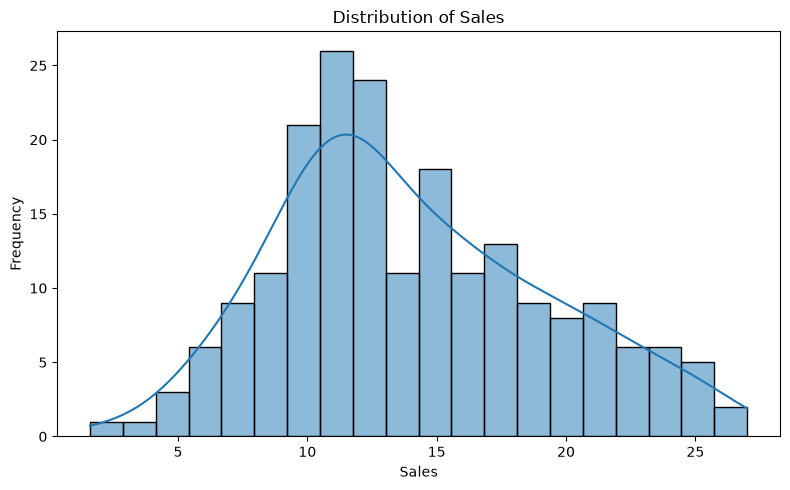

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Sales"], bins=20, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

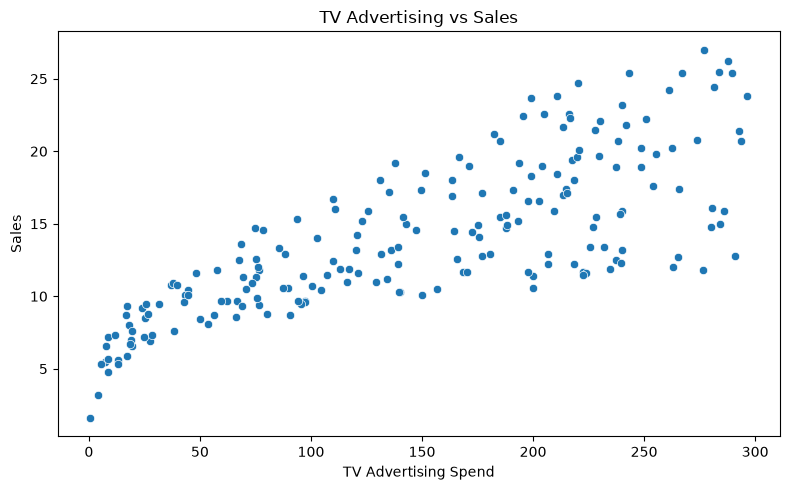

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

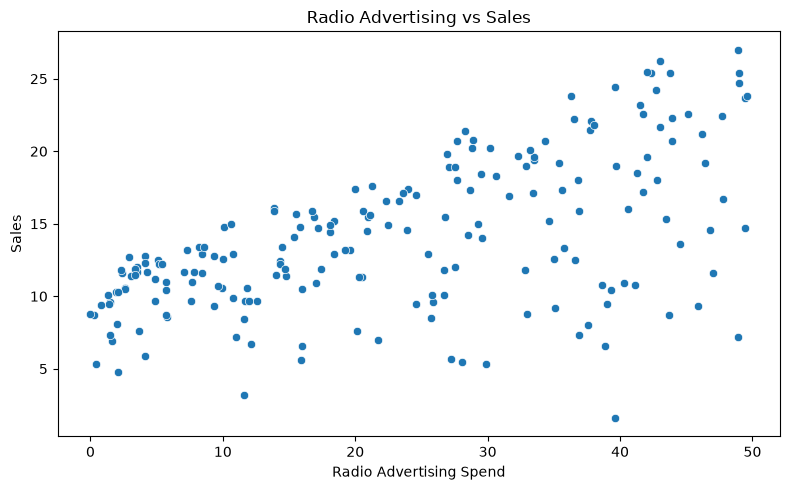

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

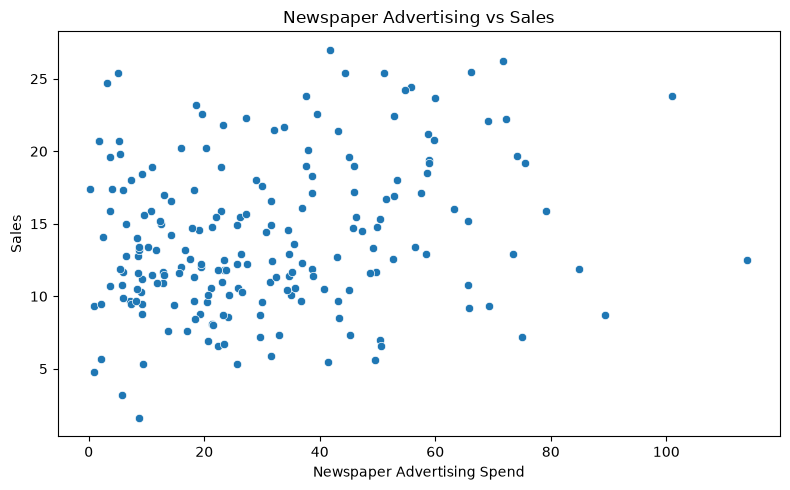

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [13]:
correlation = df.corr(numeric_only=True)

print("Correlation with Sales:")
print(correlation["Sales"].sort_values(ascending=False))

Correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


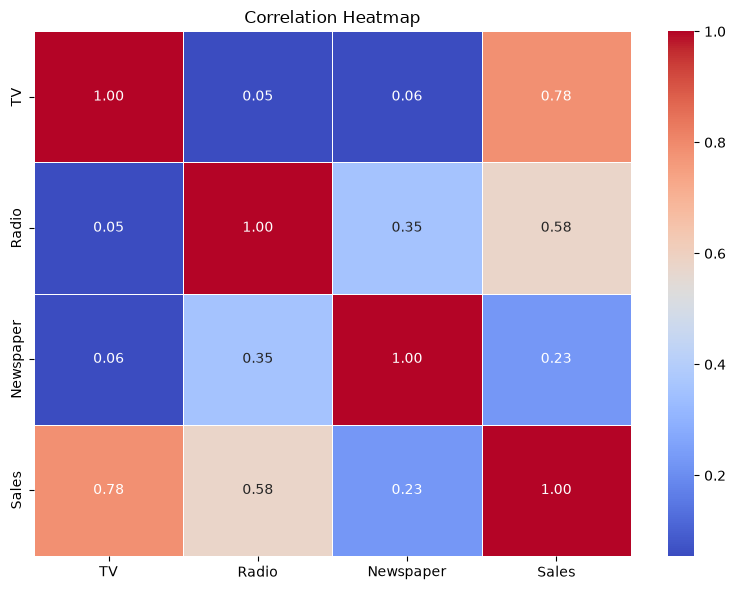

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

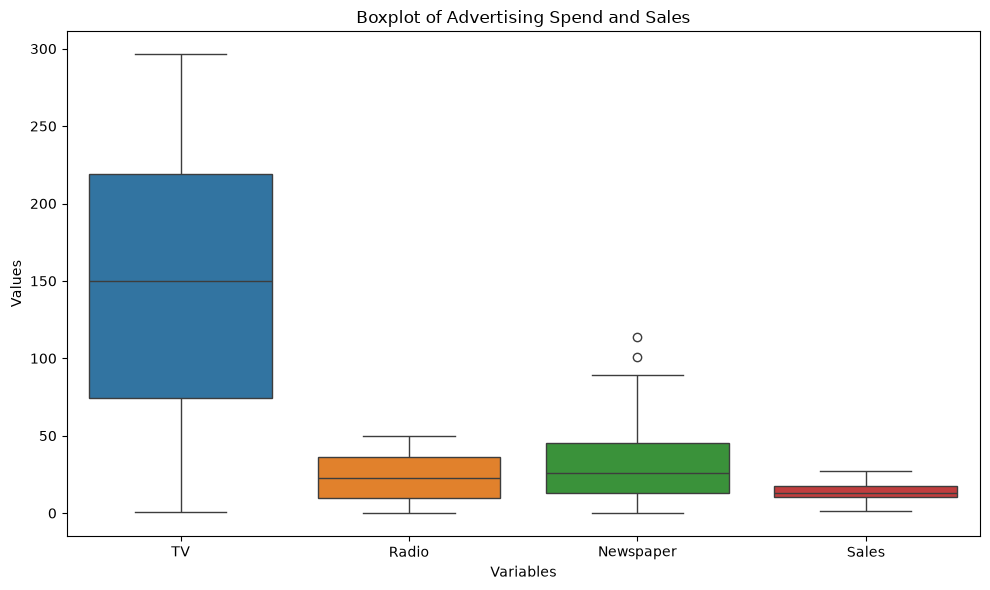

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["TV", "Radio", "Newspaper", "Sales"]])

plt.title("Boxplot of Advertising Spend and Sales")
plt.xlabel("Variables")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [16]:
Q1 = df[["TV", "Radio", "Newspaper", "Sales"]].quantile(0.25)
Q3 = df[["TV", "Radio", "Newspaper", "Sales"]].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    ((df[["TV", "Radio", "Newspaper", "Sales"]] < lower_bound) |
     (df[["TV", "Radio", "Newspaper", "Sales"]] > upper_bound))
    .sum()
)

print("Outlier Count:")
print(outlier_counts)

Outlier Count:
TV           0
Radio        0
Newspaper    2
Sales        0
dtype: int64


In [17]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Features shape: (200, 3)
Target shape: (200,)

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [19]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_linear[:10])

First 10 Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-" * 40)
print(f"MAE  : {mae_linear:.4f}")
print(f"MSE  : {mse_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Performance
----------------------------------------
MAE  : 1.4608
MSE  : 3.1741
RMSE : 1.7816
R²   : 0.8994


In [22]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("-" * 40)
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression Performance
----------------------------------------
MAE  : 1.4608
MSE  : 3.1741
RMSE : 1.7816
R²   : 0.8994


In [23]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("-" * 40)
print(f"MAE  : {mae_lasso:.4f}")
print(f"MSE  : {mse_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.4f}")
print(f"R²   : {r2_lasso:.4f}")

Lasso Regression Performance
----------------------------------------
MAE  : 1.4598
MSE  : 3.1705
RMSE : 1.7806
R²   : 0.8996


In [24]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_lasso
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso
    ],
    "R²": [
        r2_linear,
        r2_ridge,
        r2_lasso
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Ridge Regression,1.460766,1.781599,0.899438
2,Lasso Regression,1.459795,1.780596,0.899551


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 40)
print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
----------------------------------------
MAE  : 0.6139
MSE  : 0.5486
RMSE : 0.7406
R²   : 0.9826


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-" * 40)
print(f"MAE  : {mae_gb:.4f}")
print(f"MSE  : {mse_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

Gradient Boosting Performance
----------------------------------------
MAE  : 0.6084
MSE  : 0.5269
RMSE : 0.7259
R²   : 0.9833


In [27]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_lasso,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2_linear,
        r2_ridge,
        r2_lasso,
        r2_rf,
        r2_gb
    ]
})

model_comparison = model_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,MAE,RMSE,R²
0,Gradient Boosting,0.608437,0.725882,0.983307
1,Random Forest,0.613900,0.740650,0.982620
2,Lasso Regression,1.459795,1.780596,0.899551
3,Ridge Regression,1.460766,1.781599,0.899438
4,Linear Regression,1.460757,1.781600,0.899438


In [28]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )
    
    cv_results.append({
        "Model": name,
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean CV R²",
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

,Model,Mean CV R²,Std CV R²
0,Gradient Boosting,0.980709,0.005746
1,Random Forest,0.980462,0.004801
2,Lasso Regression,0.882868,0.039339
3,Ridge Regression,0.882731,0.039529
4,Linear Regression,0.882730,0.039531


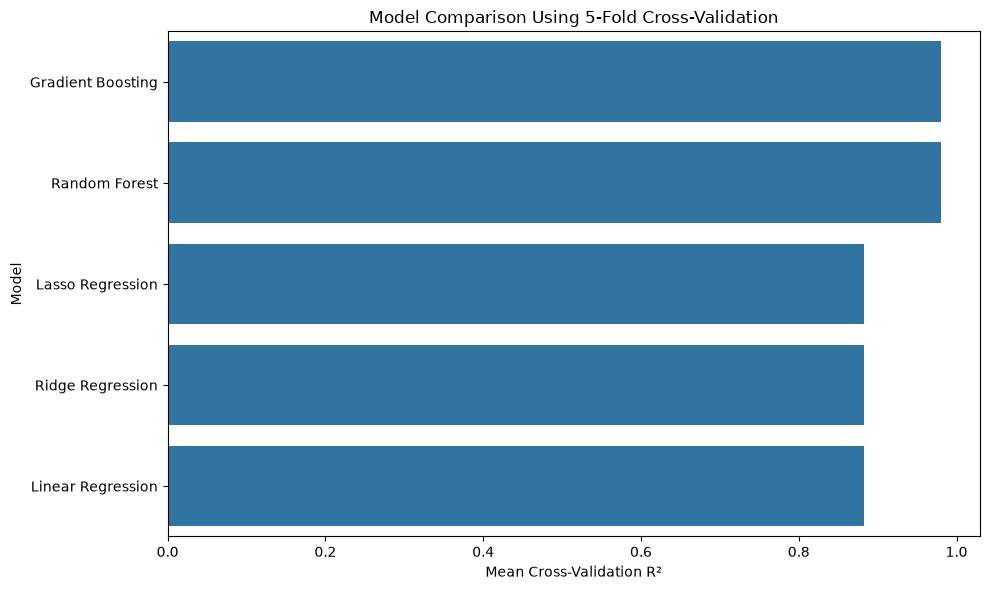

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_results_df,
    x="Mean CV R²",
    y="Model"
)

plt.title("Model Comparison Using 5-Fold Cross-Validation")
plt.xlabel("Mean Cross-Validation R²")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_base = GradientBoostingRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation R²:
0.9693


In [31]:
best_gb_model = grid_search.best_estimator_

y_pred_best_gb = best_gb_model.predict(X_test)

mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)
mse_best_gb = mean_squared_error(y_test, y_pred_best_gb)
rmse_best_gb = np.sqrt(mse_best_gb)
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print("Tuned Gradient Boosting Performance")
print("-" * 45)
print(f"MAE  : {mae_best_gb:.4f}")
print(f"MSE  : {mse_best_gb:.4f}")
print(f"RMSE : {rmse_best_gb:.4f}")
print(f"R²   : {r2_best_gb:.4f}")


Tuned Gradient Boosting Performance
---------------------------------------------
MAE  : 0.6481
MSE  : 0.6297
RMSE : 0.7935
R²   : 0.9801


In [32]:
final_comparison = model_comparison.copy()

tuned_result = pd.DataFrame({
    "Model": ["Tuned Gradient Boosting"],
    "MAE": [mae_best_gb],
    "RMSE": [rmse_best_gb],
    "R²": [r2_best_gb]
})

final_comparison = pd.concat(
    [final_comparison, tuned_result],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

display(final_comparison)

,Model,MAE,RMSE,R²
0,Gradient Boosting,0.608437,0.725882,0.983307
1,Random Forest,0.613900,0.740650,0.982620
2,Tuned Gradient Boosting,0.648115,0.793525,0.980050
3,Lasso Regression,1.459795,1.780596,0.899551
4,Ridge Regression,1.460766,1.781599,0.899438
5,Linear Regression,1.460757,1.781600,0.899438


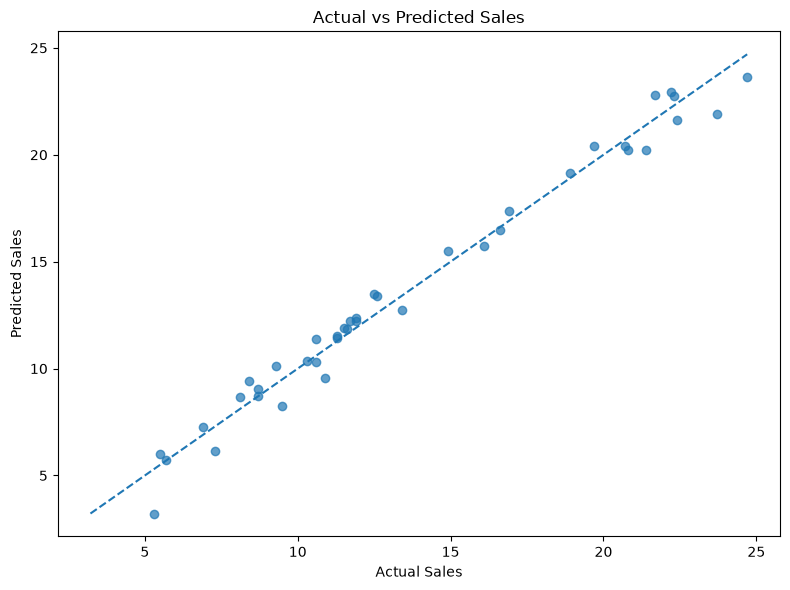

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best_gb,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_best_gb.min())
max_value = max(y_test.max(), y_pred_best_gb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

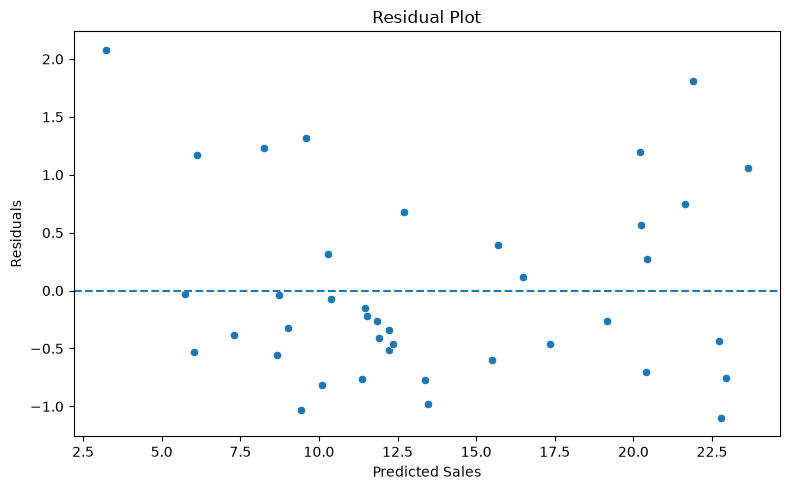

In [34]:
residuals = y_test - y_pred_best_gb

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_best_gb,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

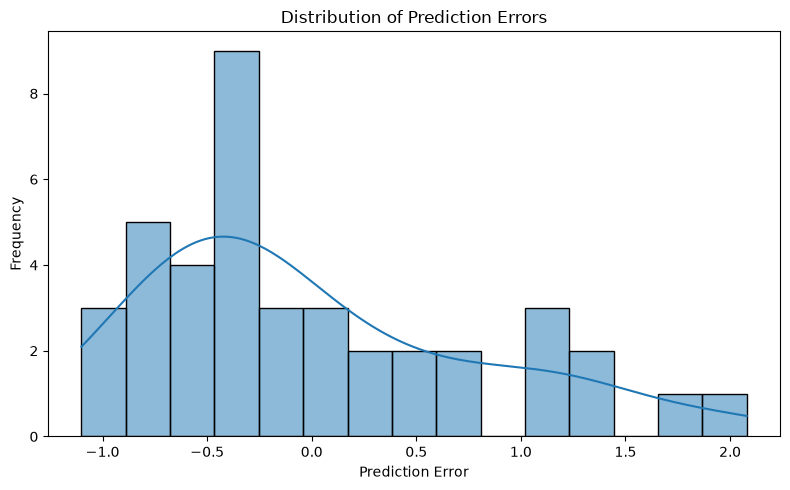

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=15,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,TV,0.611355
1,Radio,0.381961
2,Newspaper,0.006684


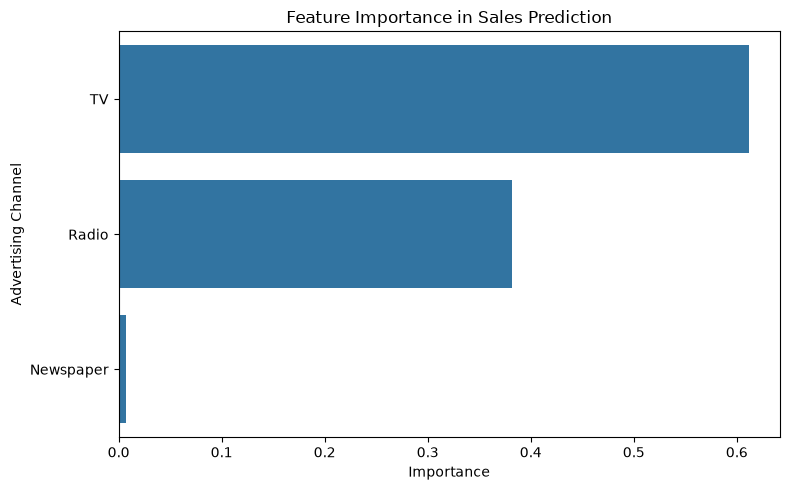

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Sales Prediction")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

In [38]:
correlation_with_sales = (
    df[["TV", "Radio", "Newspaper", "Sales"]]
    .corr()["Sales"]
    .drop("Sales")
    .abs()
    .sort_values(ascending=False)
)

comparison = pd.DataFrame({
    "Correlation with Sales": correlation_with_sales,
    "Model Importance": feature_importance.set_index("Feature")["Importance"]
})

comparison = comparison.sort_values(
    by="Model Importance",
    ascending=False
)

display(comparison)

,Correlation with Sales,Model Importance
TV,0.782224,0.611355
Radio,0.576223,0.381961
Newspaper,0.228299,0.006684


In [39]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_best_gb,
    "Error": y_test.values - y_pred_best_gb
})

results["Absolute Error"] = results["Error"].abs()

display(results.head(10))

,Actual Sales,Predicted Sales,Error,Absolute Error
0,16.9,17.363300,-0.463300,0.463300
1,22.4,21.648181,0.751819,0.751819
2,21.4,20.202827,1.197173,1.197173
3,7.3,6.127534,1.172466,1.172466
4,24.7,23.642752,1.057248,1.057248
5,12.6,13.375326,-0.775326,0.775326
6,22.3,22.733164,-0.433164,0.433164
7,8.4,9.426943,-1.026943,1.026943
8,11.5,11.906999,-0.406999,0.406999
9,14.9,15.502735,-0.602735,0.602735


In [40]:
print("FINAL MODEL PERFORMANCE")
print("=" * 45)

print(f"MAE  : {mae_best_gb:.4f}")
print(f"RMSE : {rmse_best_gb:.4f}")
print(f"R²   : {r2_best_gb:.4f}")

FINAL MODEL PERFORMANCE
MAE  : 0.6481
RMSE : 0.7935
R²   : 0.9801


In [41]:
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

final_model.fit(X, y)

print("Final model trained successfully!")
print("Training data used:", X.shape)

Final model trained successfully!
Training data used: (200, 3)


In [42]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/sales_prediction_model.pkl"

joblib.dump(final_model, model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: ../models/sales_prediction_model.pkl
